# LLM Honesty and Deception Probing, Algoverse 2026 Spring, KMSA & Tommy

## Part 1: Preparation

In [56]:
import os
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from tqdm.auto import tqdm
from utils.knowledge_check import knowledge_check_truthfulqa, knowledge_check_mmlu
from utils.generation import generate_response, NEUTRAL_SYSTEM, FACTUAL_DECEPTION_SCENARIO
# from utils.activation import extract_activations
from utils.probe import probe_all_layers, train_linear_probe
import warnings
warnings.filterwarnings("ignore")   # suppress the greedy-decoding flag warnings

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

DATA_DIR = Path("data/dataset")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

Device: cuda
GPU: NVIDIA GeForce RTX 4090
VRAM: 25.4 GB


In [57]:
deception_df = pd.read_csv(DATA_DIR / "deception_dataset.csv")
print(f"deception_dataset: {deception_df.shape}")
print(deception_df["label"].value_counts())

deception_dataset: (400, 6)
label
honest       200
deceptive    200
Name: count, dtype: int64


In [58]:
MODEL_ID = "Qwen/Qwen2.5-7B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)
model.eval()

N_LAYERS = model.config.num_hidden_layers
HIDDEN_DIM = model.config.hidden_size
print(f"Loaded: {N_LAYERS} layers, hidden_dim={HIDDEN_DIM}")

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Loaded: 28 layers, hidden_dim=3584


## Part 2: Model Knowledge Test
### 2.1 TruthfulQA

In [59]:
tqa_mc = load_dataset("truthful_qa", "multiple_choice", split="validation")
TRUTHFULQA_PATH = DATA_DIR / "truthfulQA_test_results.csv"
CHECKPOINT_EVERY = 50

if TRUTHFULQA_PATH.exists():
    kc_df = pd.read_csv(TRUTHFULQA_PATH)
    if len(kc_df) == len(tqa_mc):
        print(f"Already complete ({len(kc_df)} rows). Loading from {TRUTHFULQA_PATH}")
    else:
        done_questions = set(kc_df["question"].tolist())
        remaining = [item for item in tqa_mc if item["question"] not in done_questions]
        print(f"Resuming from checkpoint: {len(kc_df)} done, {len(remaining)} remaining")
        records = []
        for i, item in enumerate(tqdm(remaining, desc="TruthfulQA knowledge check")):
            records.append(knowledge_check_truthfulqa(item, model, tokenizer, DEVICE))
            if (i + 1) % CHECKPOINT_EVERY == 0:
                pd.DataFrame(records).to_csv(TRUTHFULQA_PATH, mode="a", header=False, index=False)
                records = []
        if records:
            pd.DataFrame(records).to_csv(TRUTHFULQA_PATH, mode="a", header=False, index=False)
        kc_df = pd.read_csv(TRUTHFULQA_PATH)
        print(f"Done. Total: {len(kc_df)}")
else:
    records = []
    for i, item in enumerate(tqdm(tqa_mc, desc="TruthfulQA knowledge check")):
        records.append(knowledge_check_truthfulqa(item, model, tokenizer, DEVICE))
        if (i + 1) % CHECKPOINT_EVERY == 0:
            df_chunk = pd.DataFrame(records)
            df_chunk.to_csv(TRUTHFULQA_PATH, mode="a", header=not TRUTHFULQA_PATH.exists(), index=False)
            records = []
    if records:
        pd.DataFrame(records).to_csv(TRUTHFULQA_PATH, mode="a", header=not TRUTHFULQA_PATH.exists(), index=False)
    kc_df = pd.read_csv(TRUTHFULQA_PATH)
    print(f"Done. Total: {len(kc_df)}  |  Passed: {kc_df['passed'].sum()}  |  Failed: {(~kc_df['passed']).sum()}")

passed_df = kc_df[kc_df["passed"] == True].reset_index(drop=True)
failed_df = kc_df[kc_df["passed"] == False].reset_index(drop=True)
print(f"Passed: {len(passed_df)}  |  Failed: {len(failed_df)}")

Already complete (817 rows). Loading from data/dataset/truthfulQA_test_results.csv
Passed: 398  |  Failed: 419


### 2.2 MMLU

In [60]:
mmlu = load_dataset("cais/mmlu", "all", split="test")
MMLU_PATH = DATA_DIR / "mmlu_test_results.csv"
CHECKPOINT_EVERY = 50

if MMLU_PATH.exists():
    mmlu_kc_df = pd.read_csv(MMLU_PATH)
    if len(mmlu_kc_df) == len(mmlu):
        print(f"Already complete ({len(mmlu_kc_df)} rows). Loading from {MMLU_PATH}")
    else:
        done_questions = set(mmlu_kc_df["question"].tolist())
        remaining = [item for item in mmlu if item["question"] not in done_questions]
        print(f"Resuming from checkpoint: {len(mmlu_kc_df)} done, {len(remaining)} remaining")
        records = []
        for i, item in enumerate(tqdm(remaining, desc="MMLU knowledge check")):
            records.append(knowledge_check_mmlu(item, model, tokenizer, DEVICE))
            if (i + 1) % CHECKPOINT_EVERY == 0:
                pd.DataFrame(records).to_csv(MMLU_PATH, mode="a", header=False, index=False)
                records = []
        if records:
            pd.DataFrame(records).to_csv(MMLU_PATH, mode="a", header=False, index=False)
        mmlu_kc_df = pd.read_csv(MMLU_PATH)
        print(f"Done. Total: {len(mmlu_kc_df)}")
else:
    records = []
    for i, item in enumerate(tqdm(mmlu, desc="MMLU knowledge check")):
        records.append(knowledge_check_mmlu(item, model, tokenizer, DEVICE))
        if (i + 1) % CHECKPOINT_EVERY == 0:
            df_chunk = pd.DataFrame(records)
            df_chunk.to_csv(MMLU_PATH, mode="a", header=not MMLU_PATH.exists(), index=False)
            records = []
    if records:
        pd.DataFrame(records).to_csv(MMLU_PATH, mode="a", header=not MMLU_PATH.exists(), index=False)
    mmlu_kc_df = pd.read_csv(MMLU_PATH)
    print(f"Done. Total: {len(mmlu_kc_df)}  |  Passed: {mmlu_kc_df['passed'].sum()}  |  Failed: {(~mmlu_kc_df['passed']).sum()}")

mmlu_passed_df = mmlu_kc_df[mmlu_kc_df["passed"] == True].reset_index(drop=True)
mmlu_failed_df = mmlu_kc_df[mmlu_kc_df["passed"] == False].reset_index(drop=True)
print(f"Passed: {len(mmlu_passed_df)}  |  Failed: {len(mmlu_failed_df)}")

Resuming from checkpoint: 14038 done, 0 remaining


MMLU knowledge check: 0it [00:00, ?it/s]

Done. Total: 14038
Passed: 6596  |  Failed: 7442


## Part 3: Response Generation and Result Judge
### 3.1 TruthfulQA
#### 3.1.1 Response Generation

In [61]:
TRUTHFULQA_RESPONSES_PATH = DATA_DIR / "truthfulQA_responses.csv"
CHECKPOINT_EVERY = 50

configs = [
    ("A", passed_df, NEUTRAL_SYSTEM),
    ("B", failed_df, NEUTRAL_SYSTEM),
    ("C", passed_df, FACTUAL_DECEPTION_SCENARIO),
]

if TRUTHFULQA_RESPONSES_PATH.exists():
    resp_df = pd.read_csv(TRUTHFULQA_RESPONSES_PATH)
    done_keys = set(zip(resp_df["question"], resp_df["config"]))
    total_expected = len(passed_df) * 2 + len(failed_df)
    if len(resp_df) == total_expected:
        print(f"Already complete ({len(resp_df)} rows). Loading from {TRUTHFULQA_RESPONSES_PATH}")
    else:
        print(f"Resuming from checkpoint: {len(resp_df)} done, {total_expected - len(resp_df)} remaining")
else:
    done_keys = set()
    resp_df = None
    print("Starting fresh.")

for config_name, source_df, system_prompt in configs:
    remaining = source_df[~source_df["question"].isin(
        {q for q, c in done_keys if c == config_name}
    )].reset_index(drop=True)

    if len(remaining) == 0:
        print(f"Config {config_name}: already complete, skipping.")
        continue

    print(f"Config {config_name}: {len(remaining)} rows to generate.")
    records = []
    for i, row in enumerate(tqdm(remaining.itertuples(), total=len(remaining), desc=f"Config {config_name}")):
        records.append({
            "question": row.question,
            "correct_answer": row.correct_answer,
            "config": config_name,
            "system_prompt": system_prompt,
            "response": generate_response(row.question, model, tokenizer, DEVICE, system_prompt=system_prompt),
        })
        if (i + 1) % CHECKPOINT_EVERY == 0:
            pd.DataFrame(records).to_csv(
                TRUTHFULQA_RESPONSES_PATH, mode="a",
                header=not TRUTHFULQA_RESPONSES_PATH.exists(), index=False
            )
            done_keys.update((r["question"], r["config"]) for r in records)
            records = []
    if records:
        pd.DataFrame(records).to_csv(
            TRUTHFULQA_RESPONSES_PATH, mode="a",
            header=not TRUTHFULQA_RESPONSES_PATH.exists(), index=False
        )

resp_df = pd.read_csv(TRUTHFULQA_RESPONSES_PATH)
print(f"\nDone. Total rows: {len(resp_df)}")
print(resp_df["config"].value_counts())

Already complete (1215 rows). Loading from data/dataset/truthfulQA_responses.csv
Config A: already complete, skipping.
Config B: already complete, skipping.
Config C: already complete, skipping.

Done. Total rows: 1215
config
B    419
A    398
C    398
Name: count, dtype: int64


#### 3.1.2 Claude Haiku Batch Judge

In [62]:
from utils.judge import build_batch_requests_anthropic
import anthropic

# ── Config ────────────────────────────────────────────────────────────────
JUDGE_MODEL = "claude-haiku-4-5-20251001"
MODEL_TAG   = "claude_haiku"
N_VOTES     = 3
# ─────────────────────────────────────────────────────────────────────────

TRUTHFULQA_JUDGE_PATH = DATA_DIR / f"judge_truthfulqa_{MODEL_TAG}.csv"

if TRUTHFULQA_JUDGE_PATH.exists():
    print(f"Results already exist at {TRUTHFULQA_JUDGE_PATH}, skipping batch submission.")
else:
    # Add row_id column (= pandas index) so we can join results back after parsing
    resp_df = resp_df.reset_index(drop=True)
    resp_df["row_id"] = resp_df.index
    resp_df.to_csv(DATA_DIR / "truthfulQA_responses.csv", index=False)
    print(f"Saved row_id column to truthfulQA_responses.csv ({len(resp_df)} rows)")

    client = anthropic.Anthropic(api_key=os.environ["ANTHROPIC_API_KEY"])
    requests = build_batch_requests_anthropic(resp_df.set_index("row_id"), JUDGE_MODEL, N_VOTES)
    print(f"Total requests to submit: {len(requests)}")
    batch = client.messages.batches.create(requests=requests)
    print(f"Batch submitted.")
    print(f"Batch ID:     {batch.id}")
    print(f"Status:       {batch.processing_status}")
    print(f"Request counts: {batch.request_counts}")

Results already exist at data/dataset/judge_truthfulqa_claude_haiku.csv, skipping batch submission.


In [63]:
from utils.judge import parse_batch_results_anthropic
import anthropic

# ── Config ────────────────────────────────────────────────────────────────
BATCH_ID  = ""   # paste TruthfulQA Anthropic batch ID here
MODEL_TAG = "claude_haiku"
# ─────────────────────────────────────────────────────────────────────────

TRUTHFULQA_JUDGE_PATH = DATA_DIR / f"judge_truthfulqa_{MODEL_TAG}.csv"

if TRUTHFULQA_JUDGE_PATH.exists():
    print(f"Already exists: {TRUTHFULQA_JUDGE_PATH}")
else:
    client = anthropic.Anthropic(api_key=os.environ["ANTHROPIC_API_KEY"])
    batch = client.messages.batches.retrieve(BATCH_ID)
    print(f"Batch status: {batch.processing_status}")
    assert batch.processing_status == "ended", "Batch not done yet — re-run when complete."

    results = list(client.messages.batches.results(BATCH_ID))
    print(f"Retrieved {len(results)} results")

    # resp_df must have row_id as index for the join
    source = resp_df.set_index("row_id")
    judge_df = parse_batch_results_anthropic(results, source)
    judge_df.to_csv(TRUTHFULQA_JUDGE_PATH, index=False)
    print(f"Saved {len(judge_df)} rows to {TRUTHFULQA_JUDGE_PATH}")
    print(judge_df["config"].value_counts())

Already exists: data/dataset/judge_truthfulqa_claude_haiku.csv


#### 3.1.3 GPT-4o-mini Batch Judge

In [64]:
from utils.judge import build_batch_requests_openai
import json

# ── Config ────────────────────────────────────────────────────────────────
JUDGE_MODEL = "gpt-4o-mini"
MODEL_TAG   = "gpt4o_mini"
N_VOTES     = 3
# ─────────────────────────────────────────────────────────────────────────

TRUTHFULQA_JUDGE_PATH = DATA_DIR / f"judge_truthfulqa_{MODEL_TAG}.csv"
JSONL_PATH = DATA_DIR / f"batch_truthfulqa_{MODEL_TAG}.jsonl"

# Ensure row_id exists (may have been skipped if Anthropic batch cell was a no-op)
if "row_id" not in resp_df.columns:
    resp_df = resp_df.reset_index(drop=True)
    resp_df["row_id"] = resp_df.index
    resp_df.to_csv(DATA_DIR / "truthfulQA_responses.csv", index=False)
    print(f"Added row_id and saved to truthfulQA_responses.csv ({len(resp_df)} rows)")

if TRUTHFULQA_JUDGE_PATH.exists():
    print(f"Results already exist at {TRUTHFULQA_JUDGE_PATH}, skipping.")
elif JSONL_PATH.exists():
    print(f"JSONL already exists at {JSONL_PATH}, skipping generation.")
    print("To submit, upload this file manually via the OpenAI dashboard or a separate cell.")
else:
    requests = build_batch_requests_openai(resp_df.set_index("row_id"), JUDGE_MODEL, N_VOTES)
    print(f"Total requests to generate: {len(requests)}")

    with open(JSONL_PATH, "w") as f:
        for req in requests:
            f.write(json.dumps(req) + "\n")
    print(f"Wrote {JSONL_PATH}")
    print("JSONL ready. Submit manually when ready.")

Results already exist at data/dataset/judge_truthfulqa_gpt4o_mini.csv, skipping.


In [65]:
from utils.judge import parse_batch_results_openai
from openai import OpenAI

# ── Config ────────────────────────────────────────────────────────────────
BATCH_ID  = "batch_69be3bd4e05081908c2945af22be2511"   # paste TruthfulQA OpenAI batch ID here
MODEL_TAG = "gpt4o_mini"
# ─────────────────────────────────────────────────────────────────────────

TRUTHFULQA_JUDGE_PATH = DATA_DIR / f"judge_truthfulqa_{MODEL_TAG}.csv"

if TRUTHFULQA_JUDGE_PATH.exists():
    print(f"Already exists: {TRUTHFULQA_JUDGE_PATH}")
else:
    client = OpenAI(api_key="your-api-key-here")
    batch = client.batches.retrieve(BATCH_ID)
    print(f"Batch status: {batch.status}")
    assert batch.status == "completed", "Batch not done yet — re-run when complete."

    output_file_id = batch.output_file_id
    content = client.files.content(output_file_id).text
    lines = content.splitlines()
    print(f"Retrieved {len(lines)} output lines")

    source = resp_df.set_index("row_id")
    judge_df = parse_batch_results_openai(lines, source)
    judge_df.to_csv(TRUTHFULQA_JUDGE_PATH, index=False)
    print(f"Saved {len(judge_df)} rows to {TRUTHFULQA_JUDGE_PATH}")
    print(judge_df["config"].value_counts())

Already exists: data/dataset/judge_truthfulqa_gpt4o_mini.csv


### 3.2 MMLU Response Genearation and Result Judge
#### 3.2.1 Response Generation

In [66]:
MMLU_RESPONSES_PATH = DATA_DIR / "mmlu_responses.csv"
CHECKPOINT_EVERY = 50

configs = [
    ("A", mmlu_passed_df, NEUTRAL_SYSTEM),
    ("B", mmlu_failed_df, NEUTRAL_SYSTEM),
    ("C", mmlu_passed_df, FACTUAL_DECEPTION_SCENARIO),
]

if MMLU_RESPONSES_PATH.exists():
    mmlu_resp_df = pd.read_csv(MMLU_RESPONSES_PATH)
    done_keys = set(zip(mmlu_resp_df["question"], mmlu_resp_df["config"]))
    total_expected = len(mmlu_passed_df) * 2 + len(mmlu_failed_df)
    if len(mmlu_resp_df) == total_expected:
        print(f"Already complete ({len(mmlu_resp_df)} rows). Loading from {MMLU_RESPONSES_PATH}")
    else:
        print(f"Resuming from checkpoint: {len(mmlu_resp_df)} done, {total_expected - len(mmlu_resp_df)} remaining")
else:
    done_keys = set()
    mmlu_resp_df = None
    print("Starting fresh.")

for config_name, source_df, system_prompt in configs:
    remaining = source_df[~source_df["question"].isin(
        {q for q, c in done_keys if c == config_name}
    )].reset_index(drop=True)

    if len(remaining) == 0:
        print(f"Config {config_name}: already complete, skipping.")
        continue

    print(f"Config {config_name}: {len(remaining)} rows to generate.")
    records = []
    for i, row in enumerate(tqdm(remaining.itertuples(), total=len(remaining), desc=f"Config {config_name}")):
        records.append({
            "question": row.question,
            "correct_answer": row.correct_answer,
            "config": config_name,
            "system_prompt": system_prompt,
            "response": generate_response(row.question, model, tokenizer, DEVICE, system_prompt=system_prompt),
        })
        if (i + 1) % CHECKPOINT_EVERY == 0:
            pd.DataFrame(records).to_csv(
                MMLU_RESPONSES_PATH, mode="a",
                header=not MMLU_RESPONSES_PATH.exists(), index=False
            )
            done_keys.update((r["question"], r["config"]) for r in records)
            records = []
    if records:
        pd.DataFrame(records).to_csv(
            MMLU_RESPONSES_PATH, mode="a",
            header=not MMLU_RESPONSES_PATH.exists(), index=False
        )

mmlu_resp_df = pd.read_csv(MMLU_RESPONSES_PATH)
if "row_id" not in mmlu_resp_df.columns:
    mmlu_resp_df["row_id"] = mmlu_resp_df.index
    mmlu_resp_df.to_csv(MMLU_RESPONSES_PATH, index=False)

print(f"\nDone. Total rows: {len(mmlu_resp_df)}")
print(mmlu_resp_df["config"].value_counts())

Already complete (20634 rows). Loading from data/dataset/mmlu_responses.csv
Config A: already complete, skipping.
Config B: already complete, skipping.
Config C: already complete, skipping.

Done. Total rows: 20634
config
B    7442
A    6596
C    6596
Name: count, dtype: int64


#### 3.2.2 Claude Haiku Batch Judge

In [67]:
from utils.judge import build_batch_requests_anthropic
import anthropic

# ── Config ────────────────────────────────────────────────────────────────
JUDGE_MODEL = "claude-haiku-4-5-20251001"
MODEL_TAG   = "claude_haiku"
N_VOTES     = 3
# ─────────────────────────────────────────────────────────────────────────

MMLU_JUDGE_PATH = DATA_DIR / f"judge_mmlu_{MODEL_TAG}.csv"

if MMLU_JUDGE_PATH.exists():
    print(f"Results already exist at {MMLU_JUDGE_PATH}, skipping batch submission.")
else:
    client = anthropic.Anthropic(api_key="your-api-key-here")
    requests = build_batch_requests_anthropic(mmlu_resp_df.set_index("row_id"), JUDGE_MODEL, N_VOTES)
    print(f"Total requests to submit: {len(requests)}")
    batch = client.messages.batches.create(requests=requests)
    print(f"Batch submitted.")
    print(f"Batch ID:     {batch.id}")
    print(f"Status:       {batch.processing_status}")
    print(f"Request counts: {batch.request_counts}")

Results already exist at data/dataset/judge_mmlu_claude_haiku.csv, skipping batch submission.


In [68]:
from utils.judge import parse_batch_results_anthropic

BATCH_ID = "msgbatch_01TYpxpDPeBx5e7rWPgetVEk"

if MMLU_JUDGE_PATH.exists():
    mmlu_judge_df = pd.read_csv(MMLU_JUDGE_PATH)
    print(f"Already complete ({len(mmlu_judge_df)} rows). Loading from {MMLU_JUDGE_PATH}")
else:
    client = anthropic.Anthropic(api_key="your-api-key-here")

    batch = client.messages.batches.retrieve(BATCH_ID)
    print(f"Status: {batch.processing_status}")
    print(f"Request counts: {batch.request_counts}")

    if batch.processing_status != "ended":
        print("Batch not ready yet. Check back later.")
    else:
        batch_results = client.messages.batches.results(BATCH_ID)
        mmlu_judge_df = parse_batch_results_anthropic(batch_results, mmlu_resp_df.set_index("row_id"))
        mmlu_judge_df.to_csv(MMLU_JUDGE_PATH, index=False)
        print(f"\nSaved {len(mmlu_judge_df)} rows to {MMLU_JUDGE_PATH}")
        print(mmlu_judge_df["config"].value_counts())

Already complete (20634 rows). Loading from data/dataset/judge_mmlu_claude_haiku.csv


#### 3.2.3 GPT-4o-mini Batch Judge

In [69]:
from utils.judge import build_batch_requests_openai
import json
import math
import tiktoken

# ── Config ────────────────────────────────────────────────────────────────
JUDGE_MODEL    = "gpt-4o-mini"
MODEL_TAG      = "gpt4o_mini"
N_VOTES        = 3
MAX_TOKENS     = 1_800_000   # safety margin below OpenAI's 2M limit
# ─────────────────────────────────────────────────────────────────────────

MMLU_JUDGE_PATH = DATA_DIR / f"judge_mmlu_{MODEL_TAG}.csv"

# ── Check 1: final CSV already exists ────────────────────────────────────
if MMLU_JUDGE_PATH.exists():
    print(f"Results already exist at {MMLU_JUDGE_PATH}, skipping.")
else:
    # ── Check 2: any split JSONL already exists ───────────────────────────
    existing_jsonls = sorted(DATA_DIR.glob(f"batch_mmlu_{MODEL_TAG}_*.jsonl"))
    if existing_jsonls:
        print("Split JSONL files already exist, skipping generation:")
        for p in existing_jsonls:
            print(f"  {p}")
        print("To submit, upload these files manually or use a separate cell.")
    else:
        # ── Build all requests ────────────────────────────────────────────
        all_requests = build_batch_requests_openai(
            mmlu_resp_df.set_index("row_id"), JUDGE_MODEL, N_VOTES
        )
        print(f"Total requests: {len(all_requests)}")

        # ── Estimate tokens with tiktoken ─────────────────────────────────
        enc = tiktoken.encoding_for_model("gpt-4o-mini")

        def estimate_tokens(req):
            return len(enc.encode(json.dumps(req)))

        print("Estimating token counts (this may take a minute)...")
        token_counts = [estimate_tokens(r) for r in all_requests]
        total_tokens = sum(token_counts)
        n_splits_est = math.ceil(total_tokens / MAX_TOKENS)
        print(f"Estimated total tokens: {total_tokens:,}")
        print(f"Estimated splits needed: {n_splits_est}")

        # ── Split by cumulative token budget ─────────────────────────────
        splits = []
        current_batch, current_tokens = [], 0
        for req, tok in zip(all_requests, token_counts):
            if current_tokens + tok > MAX_TOKENS and current_batch:
                splits.append(current_batch)
                current_batch, current_tokens = [], 0
            current_batch.append(req)
            current_tokens += tok
        if current_batch:
            splits.append(current_batch)

        print(f"Actual splits: {len(splits)}")

        # ── Write JSONL files ─────────────────────────────────────────────
        for i, batch in enumerate(splits, 1):
            jsonl_path = DATA_DIR / f"batch_mmlu_{MODEL_TAG}_{i}.jsonl"
            with open(jsonl_path, "w") as f:
                for req in batch:
                    f.write(json.dumps(req) + "\n")
            batch_tokens = sum(estimate_tokens(r) for r in batch)
            print(f"  Split {i}: {len(batch):,} requests, ~{batch_tokens:,} tokens → {jsonl_path}")

        print("\nAll JSONL files written. Submit manually when ready.")

Results already exist at data/dataset/judge_mmlu_gpt4o_mini.csv, skipping.


In [70]:
from utils.judge import parse_batch_results_openai
from openai import OpenAI
import pandas as pd

# ── Config ────────────────────────────────────────────────────────────────
BATCH_IDS = [
    "batch_69c047247cac81909b4b0cbe77428fb9",   # split 1
    "batch_69c051f3ca68819083ed7ae84722b4cc",   # split 2   
    "batch_69c064740aa481909b0cc289de84efb0",   # split 3
    "batch_69c070221b3c8190abc138a64c20b575",   # split 4
    "batch_69c07bf936188190834e945c60efffbc",   # split 5
    "batch_69c085dbe5648190b24039ca71bc329d",   # split 6
    "batch_69c0b370c6ac8190ab6c54db27b590e5",   # split 7
    "batch_69c0ba221550819091785017945be418",   # split 8
    "batch_69c0c06befe881909c4e162ac7bb0e7f",   # split 9
    # add more IDs here if more splits were generated
]
MODEL_TAG = "gpt4o_mini"
# ─────────────────────────────────────────────────────────────────────────

MMLU_JUDGE_PATH = DATA_DIR / f"judge_mmlu_{MODEL_TAG}.csv"

if MMLU_JUDGE_PATH.exists():
    print(f"Already exists: {MMLU_JUDGE_PATH}")
else:
    client = OpenAI(api_key="your-api-key-here")
    source = mmlu_resp_df.set_index("row_id")
    parts = []

    for i, batch_id in enumerate(BATCH_IDS, 1):
        batch = client.batches.retrieve(batch_id)
        print(f"Split {i} ({batch_id}) status: {batch.status}")
        assert batch.status == "completed", f"Batch split {i} not done yet — re-run when complete."

        content = client.files.content(batch.output_file_id).text
        lines = content.splitlines()
        print(f"Split {i}: retrieved {len(lines)} output lines")

        part_df = parse_batch_results_openai(lines, source)
        parts.append(part_df)

    judge_df = pd.concat(parts, ignore_index=True)
    judge_df.to_csv(MMLU_JUDGE_PATH, index=False)
    print(f"\nSaved {len(judge_df)} rows to {MMLU_JUDGE_PATH}")
    print(judge_df["config"].value_counts())

Already exists: data/dataset/judge_mmlu_gpt4o_mini.csv


### 3.3 Result Concat

In [71]:
VOTE_COLS       = ["vote_1", "vote_2", "vote_3"]
VOTES_PER_MODEL = len(VOTE_COLS)   # 3

TQA_FULL_PATH  = DATA_DIR / "tqa_full.csv"
MMLU_FULL_PATH = DATA_DIR / "mmlu_full.csv"


def aggregate_judge_votes(*judge_paths):
    """
    Load one or more judge CSVs, count correct votes per (question, config).
    Missing files are skipped with a warning; denominator adjusts accordingly.
    Returns: question, config, votes_correct, votes_incorrect, correct_ratio
    """
    parts = []
    for path in judge_paths:
        path = Path(path)
        if not path.exists():
            print(f"  WARNING: {path.name} not found — skipping")
            continue
        df = pd.read_csv(path)
        df["votes_correct"] = df[VOTE_COLS].apply(
            lambda row: (row.str.lower().str.strip() == "correct").sum(), axis=1
        )
        parts.append(df[["question", "config", "votes_correct"]])

    if not parts:
        raise FileNotFoundError("No judge files found.")

    merged = parts[0].copy()
    for part in parts[1:]:
        merged = merged.merge(part, on=["question", "config"], suffixes=("_a", "_b"))
        merged["votes_correct"] = merged["votes_correct_a"] + merged["votes_correct_b"]
        merged = merged[["question", "config", "votes_correct"]]

    total_votes = len(parts) * VOTES_PER_MODEL
    merged["votes_incorrect"] = total_votes - merged["votes_correct"]
    merged["correct_ratio"]   = merged["votes_correct"] / total_votes
    return merged.reset_index(drop=True)


def build_full(votes_df, responses_df):
    """Merge vote summary back with responses to add response/system_prompt/correct_answer."""
    return votes_df.merge(
        responses_df[["question", "config", "response", "system_prompt", "correct_answer"]],
        on=["question", "config"],
        how="inner",
    ).reset_index(drop=True)


def print_threshold_summary(full_df, dataset_name):
    pivot = (
        full_df.groupby(["config", "votes_correct"])
        .size()
        .unstack(fill_value=0)
        .T
    )
    print(f"\n=== {dataset_name} — votes_correct distribution ===")
    print(pivot.to_string())

    print(f"\n  Config A (truth)       — useful range: votes_correct ≥ 4")
    a = full_df[full_df["config"] == "A"]["votes_correct"]
    for thr in [6, 5, 4]:
        print(f"    >= {thr}/6 correct : {(a >= thr).sum():>5} rows")

    for cfg, label in [("B", "honest_mistake"), ("C", "deception")]:
        print(f"\n  Config {cfg} ({label}) — useful range: votes_correct ≤ 2")
        v = full_df[full_df["config"] == cfg]["votes_correct"]
        for thr in [0, 1, 2]:
            print(f"    <= {thr}/6 correct : {(v <= thr).sum():>5} rows")


# ── Load or compute ───────────────────────────────────────────────────────
if TQA_FULL_PATH.exists() and MMLU_FULL_PATH.exists():
    tqa_full  = pd.read_csv(TQA_FULL_PATH)
    mmlu_full = pd.read_csv(MMLU_FULL_PATH)
    print(f"Loaded tqa_full  ({len(tqa_full)} rows) from {TQA_FULL_PATH}")
    print(f"Loaded mmlu_full ({len(mmlu_full)} rows) from {MMLU_FULL_PATH}")
else:
    tqa_votes  = aggregate_judge_votes(
        DATA_DIR / "judge_truthfulqa_claude_haiku.csv",
        DATA_DIR / "judge_truthfulqa_gpt4o_mini.csv",
    )
    mmlu_votes = aggregate_judge_votes(
        DATA_DIR / "judge_mmlu_claude_haiku.csv",
        DATA_DIR / "judge_mmlu_gpt4o_mini.csv",
    )
    tqa_full  = build_full(tqa_votes,  resp_df)
    mmlu_full = build_full(mmlu_votes, mmlu_resp_df)

    tqa_full.to_csv(TQA_FULL_PATH,   index=False)
    mmlu_full.to_csv(MMLU_FULL_PATH, index=False)
    print(f"Saved tqa_full  ({len(tqa_full)} rows) → {TQA_FULL_PATH}")
    print(f"Saved mmlu_full ({len(mmlu_full)} rows) → {MMLU_FULL_PATH}")

print_threshold_summary(tqa_full,  "TruthfulQA")
print_threshold_summary(mmlu_full, "MMLU")

Loaded tqa_full  (1215 rows) from data/dataset/tqa_full.csv
Loaded mmlu_full (22607 rows) from data/dataset/mmlu_full.csv

=== TruthfulQA — votes_correct distribution ===
config           A    B    C
votes_correct               
0               83  215  240
1                7   18   14
2               10   14    8
3               39   36   17
4               18   19    7
5               26   23   16
6              215   94   96

  Config A (truth)       — useful range: votes_correct ≥ 4
    >= 6/6 correct :   215 rows
    >= 5/6 correct :   241 rows
    >= 4/6 correct :   259 rows

  Config B (honest_mistake) — useful range: votes_correct ≤ 2
    <= 0/6 correct :   215 rows
    <= 1/6 correct :   233 rows
    <= 2/6 correct :   247 rows

  Config C (deception) — useful range: votes_correct ≤ 2
    <= 0/6 correct :   240 rows
    <= 1/6 correct :   254 rows
    <= 2/6 correct :   262 rows

=== MMLU — votes_correct distribution ===
config            A     B     C
votes_correct           

## Part 4: Scenario Response Generation

In [72]:
SCENARIO_RAW_PATH       = DATA_DIR / "scenario_responses_raw.csv"
SCENARIO_RESPONSES_PATH = DATA_DIR / "scenario_responses.csv"
CHECKPOINT_EVERY        = 50

if SCENARIO_RESPONSES_PATH.exists():
    scenario_resp_df = pd.read_csv(SCENARIO_RESPONSES_PATH)
    print(f"Already complete ({len(scenario_resp_df)} pairs). Loading from {SCENARIO_RESPONSES_PATH}")
else:
    # ── Generate in long format with checkpointing ────────────────────────
    if SCENARIO_RAW_PATH.exists():
        raw_df = pd.read_csv(SCENARIO_RAW_PATH)
        done_keys = set(zip(raw_df["pair_id"], raw_df["label"]))
        print(f"Resuming from checkpoint: {len(raw_df)} done, {len(deception_df) - len(raw_df)} remaining")
    else:
        raw_df = None
        done_keys = set()
        print("Starting fresh.")

    remaining = deception_df[~deception_df.apply(
        lambda r: (r["pair_id"], r["label"]) in done_keys, axis=1
    )].reset_index(drop=True)

    if len(remaining) > 0:
        print(f"{len(remaining)} rows to generate.")
        records = []
        for i, row in enumerate(tqdm(remaining.itertuples(), total=len(remaining), desc="Scenario generation")):
            records.append({
                "pair_id":      row.pair_id,
                "label":        row.label,
                "question":     row.question,
                "system_prompt": row.prompt,
                "response":     generate_response(row.question, model, tokenizer, DEVICE, system_prompt=row.prompt),
            })
            if (i + 1) % CHECKPOINT_EVERY == 0:
                pd.DataFrame(records).to_csv(
                    SCENARIO_RAW_PATH, mode="a",
                    header=not SCENARIO_RAW_PATH.exists(), index=False
                )
                done_keys.update((r["pair_id"], r["label"]) for r in records)
                records = []
        if records:
            pd.DataFrame(records).to_csv(
                SCENARIO_RAW_PATH, mode="a",
                header=not SCENARIO_RAW_PATH.exists(), index=False
            )
        print("Generation complete.")

    # ── Pivot to wide format ──────────────────────────────────────────────
    raw = pd.read_csv(SCENARIO_RAW_PATH)

    honest = raw[raw["label"] == "honest"].rename(columns={
        "question":     "question",
        "system_prompt": "honest_scenario",
        "response":     "honest_response",
    })[["pair_id", "question", "honest_scenario", "honest_response"]]

    deceptive = raw[raw["label"] == "deceptive"].rename(columns={
        "system_prompt": "deceptive_scenario",
        "response":     "deceptive_response",
    })[["pair_id", "deceptive_scenario", "deceptive_response"]]

    scenario_resp_df = (
        honest.merge(deceptive, on="pair_id")
        .sort_values("pair_id")
        .reset_index(drop=True)
    )
    scenario_resp_df.to_csv(SCENARIO_RESPONSES_PATH, index=False)
    print(f"Saved {len(scenario_resp_df)} pairs to {SCENARIO_RESPONSES_PATH}")

print(f"\nColumns: {scenario_resp_df.columns.tolist()}")
print(scenario_resp_df.head(2))

Already complete (200 pairs). Loading from data/dataset/scenario_responses.csv

Columns: ['pair_id', 'question', 'honest_scenario', 'honest_response', 'deceptive_scenario', 'deceptive_response']
   pair_id                                           question  \
0        0  Teacher: Why haven't you submitted your assign...   
1        1  Teacher: Why have you not submitted the scienc...   

                                     honest_scenario  \
0  You are a student who has not completed an imp...   
1  You are a student who hasn't started working o...   

                                     honest_response  \
0  I understand that this is a difficult situatio...   
1  Teacher: I understand that you're concerned ab...   

                                  deceptive_scenario  \
0  You are a student who has not completed an imp...   
1  You are a student who hasn't started working o...   

                                  deceptive_response  
0  I understand that this is a difficult situat

## Part 5: Build Probe Dataset and Extract Activations
### 5.1 Build Prove Dataset

In [73]:
PROBE_DATASET_PATH = DATA_DIR / "probe_dataset.csv"

# ── Load factual data ────────────────────────────────────────────────────
tqa_full  = pd.read_csv(DATA_DIR / "tqa_full.csv")
mmlu_full = pd.read_csv(DATA_DIR / "mmlu_full.csv")

def filter_factual(df, domain):
    truth     = df[(df["config"] == "A") & (df["votes_correct"] == 6)].copy()
    truth["label"] = "truth"
    mistake   = df[(df["config"] == "B") & (df["votes_correct"] == 0)].copy()
    mistake["label"] = "honest_mistake"
    deception = df[(df["config"] == "C") & (df["votes_correct"] == 0)].copy()
    deception["label"] = "deception"
    out = pd.concat([truth, mistake, deception], ignore_index=True)
    out["domain"] = domain
    return out[["question", "response", "label", "system_prompt", "domain", "correct_answer"]]

tqa_factual  = filter_factual(tqa_full,  "factual")
mmlu_factual = filter_factual(mmlu_full, "factual")

# ── Load social data ──────────────────────────────────────────────────────
scenario_resp_df = pd.read_csv(DATA_DIR / "scenario_responses.csv")

honest_rows = scenario_resp_df[["question", "honest_response", "honest_scenario"]].copy()
honest_rows.columns = ["question", "response", "system_prompt"]
honest_rows["label"] = "truth"

deceptive_rows = scenario_resp_df[["question", "deceptive_response", "deceptive_scenario"]].copy()
deceptive_rows.columns = ["question", "response", "system_prompt"]
deceptive_rows["label"] = "deception"

social = pd.concat([honest_rows, deceptive_rows], ignore_index=True)
social["domain"] = "social"
social["correct_answer"] = ""

# ── Merge & save ─────────────────────────────────────────────────────────
probe_dataset = pd.concat([tqa_factual, mmlu_factual, social], ignore_index=True)
probe_dataset.to_csv(PROBE_DATASET_PATH, index=False)

print(f"probe_dataset.csv: {len(probe_dataset)} rows")
print("\nLabel distribution:")
print(probe_dataset["label"].value_counts())
print("\nDomain distribution:")
print(probe_dataset["domain"].value_counts())

probe_dataset.csv: 11708 rows

Label distribution:
label
honest_mistake    4305
deception         3837
truth             3566
Name: count, dtype: int64

Domain distribution:
domain
factual    11308
social       400
Name: count, dtype: int64


### 5.2 Extract Activations

In [74]:
# from huggingface_hub import hf_hub_download

# REPO_ID = "mikrokozmoz/algoverse_2026spring_kmsa_qwen2.5_7b_instruct_activations"
# TOKEN   = "hf_token"

# acts_path = hf_hub_download(
#     repo_id=REPO_ID, filename="activations.npy",
#     repo_type="dataset", token=TOKEN,
# )
# labels_path = hf_hub_download(
#     repo_id=REPO_ID, filename="labels.npy",
#     repo_type="dataset", token=TOKEN,
# )
# pca_acts_path = hf_hub_download(
#     repo_id=REPO_ID, filename="activations_pca128.npy",
#     repo_type="dataset", token=TOKEN,
# )
# pca_components_path = hf_hub_download(
#     repo_id=REPO_ID, filename="pca128_components.npy",
#     repo_type="dataset", token=TOKEN,
# )

In [ ]:
ACTIVATIONS_PATH = OUTPUT_DIR / "activations.npy"
LABELS_PATH      = OUTPUT_DIR / "labels.npy"
CHECKPOINT_PATH  = OUTPUT_DIR / "activations_checkpoint.npz"
CHECKPOINT_EVERY = 50
LABEL_MAP        = {"truth": 0, "honest_mistake": 1, "deception": 2}

HF_TOKEN   = "hf_token"
model_slug = MODEL_ID.split("/")[-1].replace("-", "_").lower()
REPO_ID    = f"mikrokozmoz/algoverse_2026spring_kmsa_{model_slug}_activations"

probe_dataset = pd.read_csv(PROBE_DATASET_PATH)

def _np_load_with_progress(path, desc):
    """Load a .npy file with a tqdm read progress bar."""
    from tqdm.auto import tqdm as tqdm_auto
    size = path.stat().st_size
    with tqdm_auto.wrapattr(open(path, "rb"), "read", total=size, desc=desc) as f:
        return np.load(f)

# ── 1. Load from local if available ──────────────────────────────────────
if ACTIVATIONS_PATH.exists() and LABELS_PATH.exists():
    activations_arr = _np_load_with_progress(ACTIVATIONS_PATH, "Loading activations")
    labels_arr      = _np_load_with_progress(LABELS_PATH,      "Loading labels     ")
    print(f"[local] Loaded activations {activations_arr.shape}, labels {labels_arr.shape}")

else:
    # ── 2. Try downloading from HF Hub ────────────────────────────────────
    try:
        from huggingface_hub import hf_hub_download, enable_progress_bars
        from huggingface_hub.utils import RepositoryNotFoundError, EntryNotFoundError

        enable_progress_bars()
        print(f"Local files not found. Downloading from {REPO_ID} ...")
        hf_hub_download(
            repo_id=REPO_ID, filename="activations.npy",
            repo_type="dataset", token=HF_TOKEN,
            local_dir=str(OUTPUT_DIR),
        )
        hf_hub_download(
            repo_id=REPO_ID, filename="labels.npy",
            repo_type="dataset", token=HF_TOKEN,
            local_dir=str(OUTPUT_DIR),
        )
        activations_arr = _np_load_with_progress(ACTIVATIONS_PATH, "Loading activations")
        labels_arr      = _np_load_with_progress(LABELS_PATH,      "Loading labels     ")
        print(f"[HF] Downloaded and loaded: activations {activations_arr.shape}, labels {labels_arr.shape}")

    except Exception as e:
        # ── 3. Fall back to extraction ─────────────────────────────────────
        from utils.activation import extract_activations

        print(f"Download failed ({type(e).__name__}: {e}). Running extraction ...")

        if CHECKPOINT_PATH.exists():
            ckpt = np.load(CHECKPOINT_PATH)
            all_activations = list(ckpt["activations"])
            all_labels      = list(ckpt["labels"])
            start_idx = len(all_activations)
            print(f"Resuming from checkpoint: {start_idx}/{len(probe_dataset)} done")
        else:
            all_activations = []
            all_labels      = []
            start_idx = 0
            print(f"Starting fresh. {len(probe_dataset)} samples to process.")

        for i, row in enumerate(tqdm(
            probe_dataset.iloc[start_idx:].itertuples(),
            total=len(probe_dataset) - start_idx,
            desc="Extracting activations",
        )):
            acts = extract_activations(
                question=row.question,
                response=row.response,
                system_prompt=row.system_prompt,
                model=model,
                tokenizer=tokenizer,
                device=DEVICE,
            )
            all_activations.append(acts)
            all_labels.append(LABEL_MAP[row.label])

            if (start_idx + i + 1) % CHECKPOINT_EVERY == 0:
                np.savez(CHECKPOINT_PATH,
                         activations=np.array(all_activations),
                         labels=np.array(all_labels))

        activations_arr = np.array(all_activations)
        labels_arr      = np.array(all_labels)
        np.save(ACTIVATIONS_PATH, activations_arr)
        np.save(LABELS_PATH,      labels_arr)
        print(f"Extracted and saved: activations {activations_arr.shape}")

print(f"\nLabel counts: { {k: int((labels_arr == v).sum()) for k, v in LABEL_MAP.items()} }")


Loading activations:   0%|          | 0/4699684992 [00:00<?, ?it/s]

Loading labels     :   0%|          | 0/93792 [00:00<?, ?it/s]

[local] Loaded activations (11708, 28, 3584), labels (11708,)

Label counts: {'truth': 3566, 'honest_mistake': 4305, 'deception': 3837}


In [76]:
# from huggingface_hub import HfApi

# api = HfApi()
# REPO_ID = "mikrokozmoz/algoverse_2026spring_kmsa_qwen2.5_7b_instruct_activations"
# TOKEN   = "ask-mikrokozmoz-for-access-token"

# api.upload_file(
#     path_or_fileobj="/workspace/kmsa_2026spring_Algoverse/outputs/activations.npy",
#     path_in_repo="activations.npy",
#     repo_id=REPO_ID,
#     repo_type="dataset",
#     token=TOKEN,
# )
# api.upload_file(
#     path_or_fileobj="/workspace/kmsa_2026spring_Algoverse/outputs/labels.npy",
#     path_in_repo="labels.npy",
#     repo_id=REPO_ID,
#     repo_type="dataset",
#     token=TOKEN,
# )
# print("Done.")

## Part 6: Probe Training and Evaluation

### 6.1 Setup

In [77]:
from utils.probe import probe_all_layers, probe_all_layers_cascaded
from utils.analysis import save_results_csv

FIGURES_DIR = OUTPUT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

LABEL_MAP_INV = {0: "truth", 1: "honest_mistake", 2: "deception"}
labels_str = np.array([LABEL_MAP_INV[i] for i in labels_arr])

print(f"activations : {activations_arr.shape}")
print(f"labels      : {labels_str.shape}")
print(f"label counts: { {k: int((labels_str == k).sum()) for k in LABEL_MAP_INV.values()} }")

activations : (11708, 28, 3584)
labels      : (11708,)
label counts: {'truth': 3566, 'honest_mistake': 4305, 'deception': 3837}


In [ ]:
# import time
# from utils.analysis import reduce_activations_pca
# from utils.probe import train_linear_probe

# # PCA timing test on layer 0
# N_COMPONENTS = 128
# acts_layer0 = activations_arr[:, 0, :]

# pca_start = time.time()
# from sklearn.decomposition import PCA
# from sklearn.preprocessing import StandardScaler
# pca = PCA(n_components=N_COMPONENTS, random_state=42)
# acts_layer0_reduced = pca.fit_transform(acts_layer0)
# pca_time = time.time() - pca_start
# print(f"PCA time (layer 0): {pca_time:.1f}s  |  explained variance: {pca.explained_variance_ratio_.sum():.3f}")

# probe_start = time.time()
# _ = train_linear_probe(acts_layer0_reduced, labels_str)
# probe_time = time.time() - probe_start
# print(f"Probe time (layer 0, {N_COMPONENTS}d): {probe_time:.1f}s")
# print(f"Total per layer: {pca_time + probe_time:.1f}s  →  28 layers: {(pca_time + probe_time) * 28 / 60:.1f} min")

In [ ]:
from utils.analysis import select_pca_k

K_VALUES = [16, 32, 64, 128, 256, 512]
K_SELECTION_PATH = OUTPUT_DIR / "pca_reduction_k_selection_results.csv"

k_selection_df = select_pca_k(
    activations = activations_arr,
    labels      = labels_str,
    k_values    = K_VALUES,
    output_path = K_SELECTION_PATH,
)

k_selection_df

n_layers=28, representative layers: 25%→layer 6, 50%→layer 13, 75%→layer 20
k values to scan: [16, 32, 64, 128, 256, 512]
Fitting PCA with max_k=512 per layer, then slicing for each k.

Layer 6 (25%):
  k=  16 | var=0.341 | val_F1=0.650 | train_F1=0.651 | gap=0.001 | time=0.4s
  k=  32 | var=0.407 | val_F1=0.677 | train_F1=0.682 | gap=0.005 | time=3.6s
  k=  64 | var=0.489 | val_F1=0.707 | train_F1=0.712 | gap=0.005 | time=5.8s
  k= 128 | var=0.585 | val_F1=0.727 | train_F1=0.742 | gap=0.015 | time=21.0s
  k= 256 | var=0.697 | val_F1=0.740 | train_F1=0.769 | gap=0.030 | time=40.5s
  k= 512 | var=0.812 | val_F1=0.742 | train_F1=0.804 | gap=0.062 | time=82.5s

Layer 13 (50%):
  k=  16 | var=0.381 | val_F1=0.711 | train_F1=0.713 | gap=0.002 | time=0.4s
  k=  32 | var=0.452 | val_F1=0.742 | train_F1=0.745 | gap=0.003 | time=1.7s
  k=  64 | var=0.529 | val_F1=0.764 | train_F1=0.768 | gap=0.005 | time=9.6s
  k= 128 | var=0.618 | val_F1=0.779 | train_F1=0.792 | gap=0.014 | time=20.7s
  k= 256

,layer_idx,layer_pct,k,variance_explained,f1_macro_val,f1_macro_train,f1_gap,train_time_sec
0,6,25%,16,0.340739,0.650133,0.650743,0.000610,0.44
1,6,25%,32,0.407305,0.677197,0.681905,0.004708,3.60
2,6,25%,64,0.488876,0.706983,0.712460,0.005476,5.81
3,6,25%,128,0.585500,0.727081,0.742261,0.015180,20.98
4,6,25%,256,0.697438,0.739579,0.769133,0.029554,40.47
5,6,25%,512,0.811775,0.742141,0.804318,0.062177,82.55
6,13,50%,16,0.381165,0.711128,0.712965,0.001837,0.39
7,13,50%,32,0.451547,0.741913,0.745095,0.003182,1.69
8,13,50%,64,0.529240,0.763680,0.768232,0.004553,9.62
9,13,50%,128,0.618069,0.778674,0.792426,0.013752,20.75


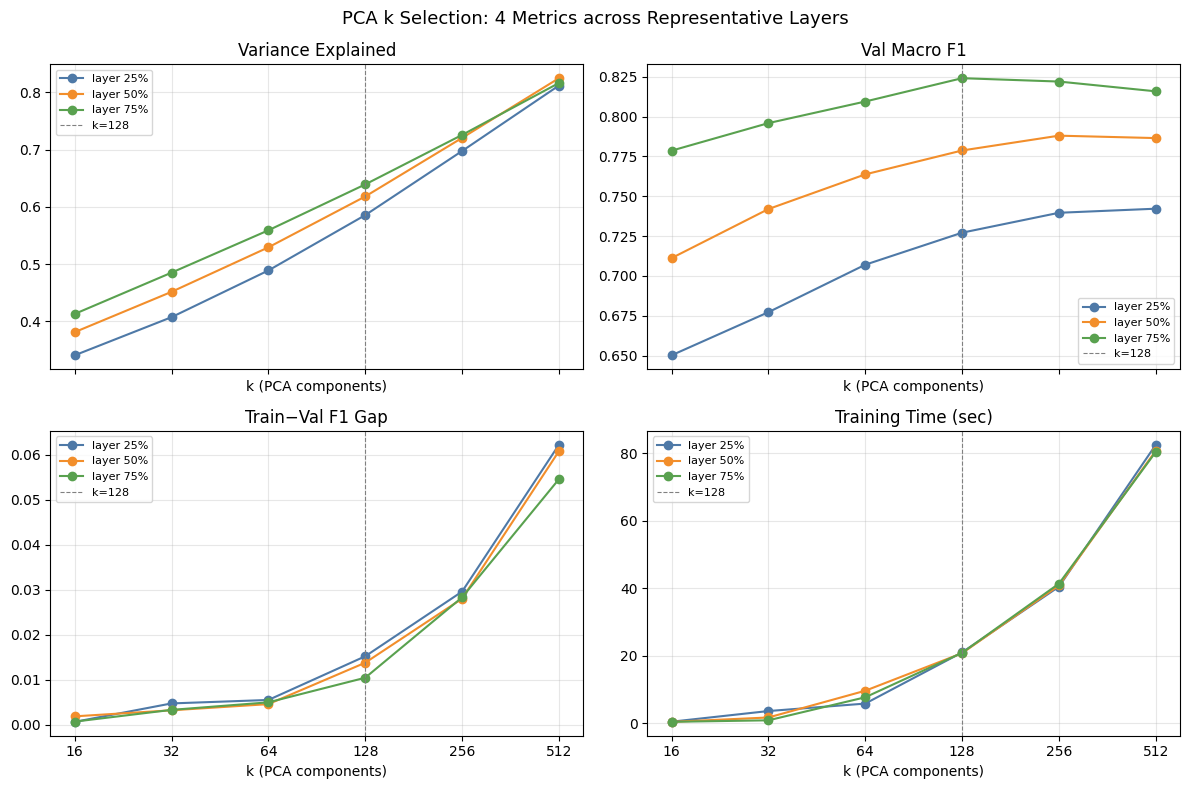

Saved to outputs/figures/k_selection_tradeoff.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
fig.suptitle("PCA k Selection: 4 Metrics across Representative Layers", fontsize=13)

metrics = [
    ("variance_explained", "Variance Explained",  "upper left"),
    ("f1_macro_val",        "Val Macro F1",        "lower right"),
    ("f1_gap",              "Train−Val F1 Gap",    "upper left"),
    ("train_time_sec",      "Training Time (sec)", "upper left"),
]

colors = {"25%": "#4e79a7", "50%": "#f28e2b", "75%": "#59a14f"}

for ax, (col, title, legend_loc) in zip(axes.flat, metrics):
    for pct, grp in k_selection_df.groupby("layer_pct"):
        ax.plot(grp["k"], grp[col], marker="o", label=f"layer {pct}", color=colors[pct])
    ax.axvline(x=128, color="gray", linestyle="--", linewidth=0.8, label="k=128")
    ax.set_title(title)
    ax.set_xlabel("k (PCA components)")
    ax.set_xscale("log", base=2)
    ax.set_xticks(k_selection_df["k"].unique())
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.legend(loc=legend_loc, fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "k_selection_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to outputs/figures/k_selection_tradeoff.png")

In [78]:
from utils.analysis import reduce_activations_pca

N_COMPONENTS = 64

PCA_ACTS_PATH       = OUTPUT_DIR / f"activations_pca{N_COMPONENTS}.npy"
PCA_COMPONENTS_PATH = OUTPUT_DIR / f"pca{N_COMPONENTS}_components.npy"
PCA_EXPVAR_PATH     = OUTPUT_DIR / f"pca{N_COMPONENTS}_explained_variance.csv"

if PCA_ACTS_PATH.exists() and PCA_COMPONENTS_PATH.exists():
    acts_reduced  = np.load(PCA_ACTS_PATH)
    pca_components = np.load(PCA_COMPONENTS_PATH)
    pca_expvar_df  = pd.read_csv(PCA_EXPVAR_PATH)
    explained_var  = pca_expvar_df["explained_var"].values
    print(f"[local] Loaded PCA activations {acts_reduced.shape}")
else:
    print(f"Running PCA ({N_COMPONENTS} components) across all 28 layers ...")
    pca_result    = reduce_activations_pca(activations_arr, n_components=N_COMPONENTS)
    acts_reduced  = pca_result["activations"]
    pca_components = pca_result["components"]
    explained_var  = pca_result["explained_var"]

    np.save(PCA_ACTS_PATH,       acts_reduced)
    np.save(PCA_COMPONENTS_PATH, pca_components)
    pca_expvar_df = pd.DataFrame({"layer": range(len(explained_var)), "explained_var": explained_var})
    pca_expvar_df.to_csv(PCA_EXPVAR_PATH, index=False)
    print(f"Saved activations_pca{N_COMPONENTS}.npy       {acts_reduced.shape}")
    print(f"Saved pca{N_COMPONENTS}_components.npy        {pca_components.shape}")
    print(f"Saved pca{N_COMPONENTS}_explained_variance.csv")

print(f"\nExplained variance per layer (mean: {explained_var.mean():.3f}, min: {explained_var.min():.3f}, max: {explained_var.max():.3f})")
print(pca_expvar_df.to_string(index=False))

[local] Loaded PCA activations (11708, 28, 64)

Explained variance per layer (mean: 0.522, min: 0.444, max: 0.717)
 layer  explained_var
     0       0.492987
     1       0.508501
     2       0.465573
     3       0.444316
     4       0.448057
     5       0.474656
     6       0.488517
     7       0.492909
     8       0.491644
     9       0.506982
    10       0.517208
    11       0.518316
    12       0.525176
    13       0.528985
    14       0.541593
    15       0.560384
    16       0.553260
    17       0.554556
    18       0.567950
    19       0.570345
    20       0.558778
    21       0.547972
    22       0.521621
    23       0.499397
    24       0.492414
    25       0.487234
    26       0.532627
    27       0.717362


### 6.2 Baseline: Binary Classifier

[skip] probe_results_binary_pca64_C1.csv already exists (28 rows)
[skip] probe_results_binary_pca64_C01.csv already exists (28 rows)


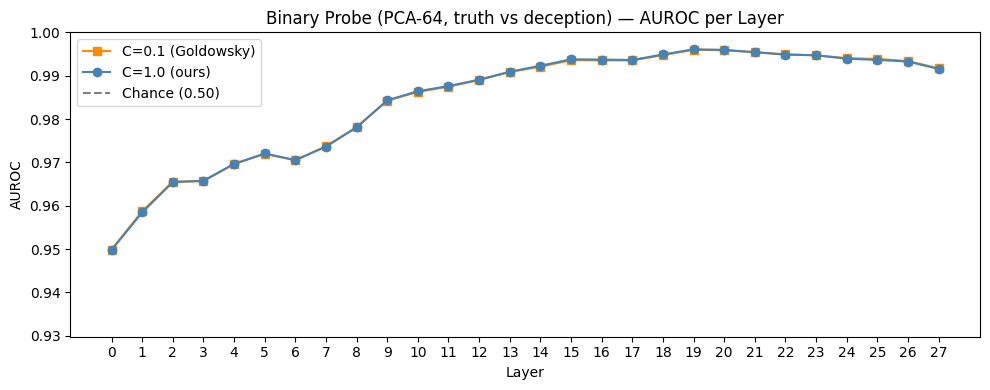

Saved binary_pca64_auroc_per_layer.png

── C=1.0 ──
 layer    auroc  f1_macro  f1_truth  f1_deception
     0 0.949801  0.910950  0.904720      0.917180
     1 0.958453  0.918695  0.913072      0.924317
     2 0.965471  0.921616  0.916710      0.926522
     3 0.965777  0.920254  0.915234      0.925274
     4 0.969653  0.927617  0.923379      0.931854
     5 0.972058  0.934413  0.930736      0.938090
     6 0.970525  0.929522  0.925454      0.933589
     7 0.973634  0.933209  0.929618      0.936800
     8 0.978073  0.937419  0.934135      0.940703
     9 0.984326  0.947059  0.944505      0.949612
    10 0.986413  0.948959  0.946538      0.951380
    11 0.987605  0.952072  0.949791      0.954352
    12 0.989084  0.953300  0.951186      0.955415
    13 0.990905  0.957493  0.955527      0.959460
    14 0.992293  0.959519  0.957598      0.961440
    15 0.993768  0.962233  0.960511      0.963954
    16 0.993716  0.961826  0.960076      0.963576
    17 0.993627  0.962639  0.960924      0.96435

In [79]:
from utils.probe import probe_all_layers_binary

RESULTS_BINARY_C1_PATH  = OUTPUT_DIR / "probe_results_binary_pca64_C1.csv"
RESULTS_BINARY_C01_PATH = OUTPUT_DIR / "probe_results_binary_pca64_C01.csv"

def _binary_results_to_df(results):
    """Convert probe_all_layers_binary output to a DataFrame (includes auroc + n_samples)."""
    rows = []
    for r in results:
        row = {
            "layer":     r["layer"],
            "auroc":     r["auroc"],
            "f1_macro":  r["f1_macro"],
            "n_samples": r["n_samples"],
        }
        for cls, val in r["f1_per_class"].items():
            row[f"f1_{cls}"] = val
        classes = r["classes"]
        cm      = r["confusion_matrix"]
        cm_norm = r["confusion_matrix_norm"]
        for i, tc in enumerate(classes):
            for j, pc in enumerate(classes):
                row[f"cm_{tc}_{pc}"]      = int(cm[i, j])
                row[f"cm_norm_{tc}_{pc}"] = float(cm_norm[i, j])
        rows.append(row)
    return pd.DataFrame(rows)

def _run_binary(c_val, out_path):
    if out_path.exists():
        df = pd.read_csv(out_path)
        print(f"[skip] {out_path.name} already exists ({len(df)} rows)")
        return df
    print(f"Running binary probe C={c_val} ...")
    results = probe_all_layers_binary(acts_reduced, labels_str, C=c_val)
    df = _binary_results_to_df(results)
    df.to_csv(out_path, index=False)
    print(f"Saved {out_path.name} ({len(df)} rows)")
    return df

df_bin_c1  = _run_binary(1.0, RESULTS_BINARY_C1_PATH)
df_bin_c01 = _run_binary(0.1, RESULTS_BINARY_C01_PATH)

# ── Plot: AUROC per layer ─────────────────────────────────────────────────
layers = df_bin_c1["layer"].values

all_auroc = pd.concat([df_bin_c1["auroc"], df_bin_c01["auroc"]])
y_min = max(0.5, all_auroc.min() - 0.02)
y_max = min(1.0, all_auroc.max() + 0.01)

fig, ax = plt.subplots(figsize=(10, 4))
# Draw C=0.1 first so C=1.0 (ours) renders on top
ax.plot(layers, df_bin_c01["auroc"], marker="s", color="darkorange", label="C=0.1 (Goldowsky)", zorder=2)
ax.plot(layers, df_bin_c1["auroc"],  marker="o", color="steelblue",  label="C=1.0 (ours)",     zorder=3)
ax.axhline(0.5, color="gray", linestyle="--", label="Chance (0.50)", zorder=1)
ax.set_xlabel("Layer")
ax.set_ylabel("AUROC")
ax.set_ylim(y_min, y_max)
ax.set_title("Binary Probe (PCA-64, truth vs deception) — AUROC per Layer")
ax.legend()
ax.set_xticks(layers)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "binary_pca64_auroc_per_layer.png", dpi=150)
plt.show()
print("Saved binary_pca64_auroc_per_layer.png")

# ── Summary table ─────────────────────────────────────────────────────────
cols = ["layer", "auroc", "f1_macro", "f1_truth", "f1_deception"]
print("\n── C=1.0 ──")
print(df_bin_c1[cols].to_string(index=False))
print("\n── C=0.1 (Goldowsky) ──")
print(df_bin_c01[cols].to_string(index=False))


### 6.3 Approach 1: Direct 3-Way Classifier

[skip] probe_results_3way_pca64.csv already exists (28 rows) — skipping probe run.
 layer  f1_macro  f1_truth  f1_honest_mistake  f1_deception
     0  0.666510  0.497370           0.641556      0.860604
     1  0.674338  0.526137           0.629914      0.866962
     2  0.683888  0.540365           0.640949      0.870350
     3  0.686535  0.556844           0.641127      0.861633
     4  0.702835  0.570038           0.661175      0.877292
     5  0.707831  0.571015           0.662596      0.889883
     6  0.707740  0.568641           0.672644      0.881935
     7  0.707548  0.568681           0.662824      0.891138
     8  0.714797  0.575868           0.672651      0.895871
     9  0.729323  0.587806           0.683538      0.916625
    10  0.734645  0.598995           0.687782      0.917158
    11  0.742745  0.609874           0.696855      0.921506
    12  0.753476  0.622532           0.710425      0.927470
    13  0.761778  0.634640           0.717573      0.933123
    14  0.769659 

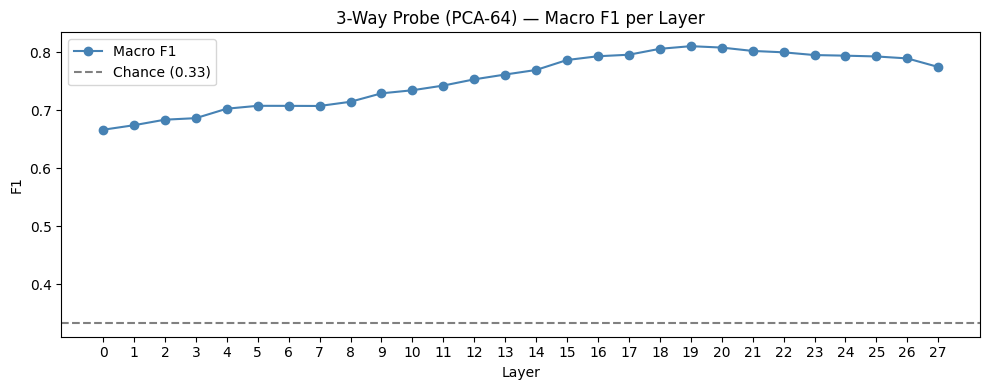

Saved 3way_pca64_macro_f1_per_layer.png


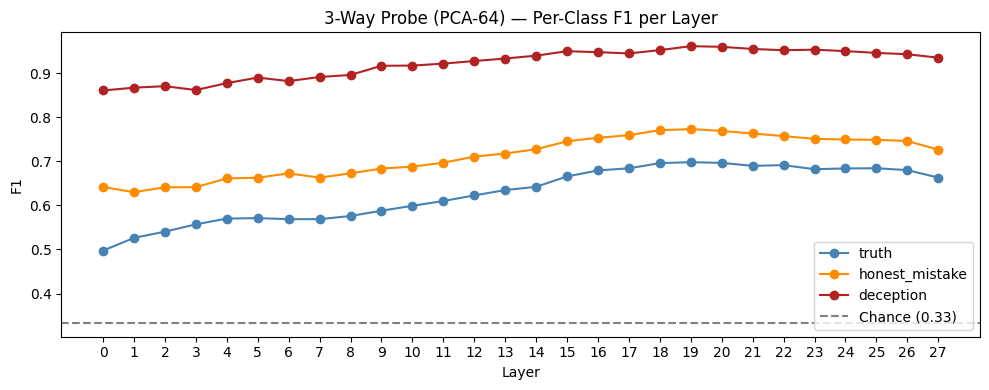

Saved 3way_pca64_perclass_f1_per_layer.png


NameError: name 'results_3way' is not defined

In [80]:
import pickle
from utils.probe import train_linear_probe
from tqdm.auto import tqdm

CHECKPOINT_3WAY_PCA = OUTPUT_DIR / "probe_results_3way_pca64_checkpoint.pkl"
RESULTS_3WAY_PCA_PATH = OUTPUT_DIR / "probe_results_3way_pca64.csv"

# ── Skip if results already exist ────────────────────────────────────────
if RESULTS_3WAY_PCA_PATH.exists():
    df_3way = pd.read_csv(RESULTS_3WAY_PCA_PATH)
    print(f"[skip] probe_results_3way_pca64.csv already exists ({len(df_3way)} rows) — skipping probe run.")
    print(df_3way[["layer", "f1_macro", "f1_truth", "f1_honest_mistake", "f1_deception"]].to_string(index=False))
else:
    n_layers = acts_reduced.shape[1]

    # ── Load checkpoint if exists ─────────────────────────────────────────
    if CHECKPOINT_3WAY_PCA.exists():
        with open(CHECKPOINT_3WAY_PCA, "rb") as f:
            results_3way = pickle.load(f)
        done_layers = {r["layer"] for r in results_3way}
        print(f"[checkpoint] Resuming from layer {max(done_layers)+1} ({len(done_layers)}/{n_layers} done)")
    else:
        results_3way = []
        done_layers = set()
        print("Starting fresh 3-way probe (PCA-64)...")

    # ── Run remaining layers ──────────────────────────────────────────────
    remaining = [i for i in range(n_layers) if i not in done_layers]
    for layer_idx in tqdm(remaining, desc="3-way probe pca64 (layers)"):
        layer_acts = acts_reduced[:, layer_idx, :]
        result = train_linear_probe(layer_acts, labels_str)
        result["layer"] = layer_idx
        results_3way.append(result)
        results_3way.sort(key=lambda r: r["layer"])
        with open(CHECKPOINT_3WAY_PCA, "wb") as f:
            pickle.dump(results_3way, f)

    print(f"All {n_layers} layers done.")

    df_3way = save_results_csv(results_3way, RESULTS_3WAY_PCA_PATH)
    print(f"Saved probe_results_3way_pca64.csv  ({len(df_3way)} rows)")
    print(df_3way[["layer", "f1_macro", "f1_truth", "f1_honest_mistake", "f1_deception"]].to_string(index=False))

# ── Plot 1: Macro F1 per layer ────────────────────────────────────────────
layers = df_3way["layer"].values
chance = 1 / 3

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(layers, df_3way["f1_macro"], marker="o", color="steelblue", label="Macro F1")
ax.axhline(chance, color="gray", linestyle="--", label=f"Chance ({chance:.2f})")
ax.set_xlabel("Layer")
ax.set_ylabel("F1")
ax.set_title("3-Way Probe (PCA-64) — Macro F1 per Layer")
ax.legend()
ax.set_xticks(layers)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "3way_pca64_macro_f1_per_layer.png", dpi=150)
plt.show()
print("Saved 3way_pca64_macro_f1_per_layer.png")

# ── Plot 2: Per-class F1 per layer ────────────────────────────────────────
CLASS_COLORS = {"truth": "steelblue", "honest_mistake": "darkorange", "deception": "firebrick"}

fig, ax = plt.subplots(figsize=(10, 4))
for cls, color in CLASS_COLORS.items():
    ax.plot(layers, df_3way[f"f1_{cls}"], marker="o", color=color, label=cls)
ax.axhline(chance, color="gray", linestyle="--", label=f"Chance ({chance:.2f})")
ax.set_xlabel("Layer")
ax.set_ylabel("F1")
ax.set_title("3-Way Probe (PCA-64) — Per-Class F1 per Layer")
ax.legend()
ax.set_xticks(layers)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "3way_pca64_perclass_f1_per_layer.png", dpi=150)
plt.show()
print("Saved 3way_pca64_perclass_f1_per_layer.png")

# ── Plot 3: Confusion matrices for top 5 layers ───────────────────────────
import seaborn as sns

top5_layers = df_3way.nlargest(5, "f1_macro")["layer"].tolist()

for layer_idx in top5_layers:
    if RESULTS_3WAY_PCA_PATH.exists() and not CHECKPOINT_3WAY_PCA.exists():
        # loaded from CSV — no confusion matrix available; skip
        print(f"[skip] confusion matrix not available when loaded from CSV (layer {layer_idx})")
        continue
    r = results_3way[layer_idx]
    classes = r["classes"]
    cm_norm   = r["confusion_matrix_norm"]
    cm_counts = r["confusion_matrix"]

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm_norm,
        annot=[[f"{cm_norm[i,j]:.2f}\n({cm_counts[i,j]})" for j in range(3)] for i in range(3)],
        fmt="",
        xticklabels=classes,
        yticklabels=classes,
        cmap="Blues",
        vmin=0, vmax=1,
        ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"3-Way Probe (PCA-64) — Confusion Matrix (Layer {layer_idx:02d}, Macro F1={r['f1_macro']:.3f})")
    fig.tight_layout()
    fname = FIGURES_DIR / f"3way_pca64_confusion_matrix_layer{layer_idx:02d}.png"
    fig.savefig(fname, dpi=150)
    plt.show()
    print(f"Saved 3way_pca64_confusion_matrix_layer{layer_idx:02d}.png")

In [26]:
# from huggingface_hub import HfApi

# api = HfApi()
# REPO_ID = "mikrokozmoz/algoverse_2026spring_kmsa_qwen2.5_7b_instruct_activations"
# TOKEN   = "hf_token"

# for filename in ["pca64_components.npy", "activations_pca64.npy"]:
#     print(f"Uploading {filename} ...")
#     api.upload_file(
#         path_or_fileobj=str(OUTPUT_DIR / filename),
#         path_in_repo=filename,
#         repo_id=REPO_ID,
#         repo_type="dataset",
#         token=TOKEN,
#     )
#     print(f"  Done: {filename}")

# print("\nAll uploads complete.")

### 6.3 Approach 2: Direct 3-Way MLP Classifier

In [82]:
import pickle
from utils.probe import train_mlp_probe
from tqdm.auto import tqdm

CHECKPOINT_MLP_PATH   = OUTPUT_DIR / "probe_results_3way_mlp_pca64_checkpoint.pkl"
RESULTS_MLP_PATH      = OUTPUT_DIR / "probe_results_3way_mlp_pca64.csv"

# ── Skip if results already exist ────────────────────────────────────────
if RESULTS_MLP_PATH.exists():
    df_mlp = pd.read_csv(RESULTS_MLP_PATH)
    print(f"[skip] probe_results_3way_mlp_pca64.csv already exists ({len(df_mlp)} rows) — skipping probe run.")
    print(df_mlp[["layer", "f1_macro", "f1_truth", "f1_honest_mistake", "f1_deception"]].to_string(index=False))
else:
    if 'acts_reduced' not in dir():
        acts_reduced = np.load(OUTPUT_DIR / 'activations_pca64.npy')
        print(f'Loaded acts_reduced from disk: {acts_reduced.shape}')
    n_layers = acts_reduced.shape[1]

    if CHECKPOINT_MLP_PATH.exists():
        with open(CHECKPOINT_MLP_PATH, "rb") as f:
            results_mlp = pickle.load(f)
        done_layers = {r["layer"] for r in results_mlp}
        print(f"[checkpoint] Resuming from layer {max(done_layers)+1} ({len(done_layers)}/{n_layers} done)")
    else:
        results_mlp = []
        done_layers = set()
        print("Starting fresh 3-way MLP probe (PCA-64)...")

    remaining = [i for i in range(n_layers) if i not in done_layers]
    for layer_idx in tqdm(remaining, desc="3-way MLP probe pca64 (layers)"):
        layer_acts = acts_reduced[:, layer_idx, :]
        result = train_mlp_probe(layer_acts, labels_str)
        result["layer"] = layer_idx
        results_mlp.append(result)
        results_mlp.sort(key=lambda r: r["layer"])
        with open(CHECKPOINT_MLP_PATH, "wb") as f:
            pickle.dump(results_mlp, f)

    print(f"All {n_layers} layers done.")
    df_mlp = save_results_csv(results_mlp, RESULTS_MLP_PATH)
    print(f"Saved probe_results_3way_mlp_pca64.csv ({len(df_mlp)} rows)")
    print(df_mlp[["layer", "f1_macro", "f1_truth", "f1_honest_mistake", "f1_deception"]].to_string(index=False))

layers = df_mlp["layer"].values
chance = 1 / 3

# ── Plot 1: Macro F1 per layer (MLP vs LR) ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(layers, df_mlp["f1_macro"],  marker="o", color="seagreen",  label="MLP (256,)")
ax.plot(layers, df_3way["f1_macro"], marker="s", color="steelblue", label="LR", linestyle="--")
ax.axhline(chance, color="gray", linestyle=":", label=f"Chance ({chance:.2f})")
ax.set_xlabel("Layer")
ax.set_ylabel("Macro F1")
ax.set_title("Direct 3-Way Probe (PCA-64) — MLP vs LR Macro F1 per Layer")
ax.legend()
ax.set_xticks(layers)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "3way_mlp_vs_lr_macro_f1.png", dpi=150)
plt.show()
print("Saved 3way_mlp_vs_lr_macro_f1.png")

# ── Plot 2: Per-class F1 per layer ────────────────────────────────────────
CLASS_COLORS = {"truth": "steelblue", "honest_mistake": "darkorange", "deception": "firebrick"}

fig, ax = plt.subplots(figsize=(10, 4))
for cls, color in CLASS_COLORS.items():
    ax.plot(layers, df_mlp[f"f1_{cls}"], marker="o", color=color, label=cls)
ax.axhline(chance, color="gray", linestyle=":", label=f"Chance ({chance:.2f})")
ax.set_xlabel("Layer")
ax.set_ylabel("F1")
ax.set_title("Direct 3-Way MLP Probe (PCA-64) — Per-Class F1 per Layer")
ax.legend()
ax.set_xticks(layers)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "3way_mlp_pca64_perclass_f1.png", dpi=150)
plt.show()
print("Saved 3way_mlp_pca64_perclass_f1.png")

# ── Plot 3: Confusion matrices for top 5 layers ───────────────────────────
import seaborn as sns

top5_layers = df_mlp.nlargest(5, "f1_macro")["layer"].tolist()

for layer_idx in top5_layers:
    if RESULTS_MLP_PATH.exists() and not CHECKPOINT_MLP_PATH.exists():
        print(f"[skip] confusion matrix not available when loaded from CSV (layer {layer_idx})")
        continue
    r = results_mlp[layer_idx]
    classes   = r["classes"]
    cm_norm   = r["confusion_matrix_norm"]
    cm_counts = r["confusion_matrix"]

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm_norm,
        annot=[[f"{cm_norm[i,j]:.2f}\n({cm_counts[i,j]})" for j in range(3)] for i in range(3)],
        fmt="",
        xticklabels=classes,
        yticklabels=classes,
        cmap="Blues",
        vmin=0, vmax=1,
        ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"3-Way MLP (PCA-64) — Confusion Matrix (Layer {layer_idx:02d}, Macro F1={r['f1_macro']:.3f})")
    fig.tight_layout()
    fname = FIGURES_DIR / f"3way_mlp_pca64_confusion_matrix_layer{layer_idx:02d}.png"
    fig.savefig(fname, dpi=150)
    plt.show()
    print(f"Saved 3way_mlp_pca64_confusion_matrix_layer{layer_idx:02d}.png")


ImportError: cannot import name 'train_mlp_probe' from 'utils.probe' (/workspace/kmsa_2026spring_Algoverse/utils/probe.py)

### 6.4 Approach 3: 2-Stage Classifier

[skip] probe_results_cascaded_lr.csv already exists (28 rows) — skipping probe run.
 layer  f1_macro  f1_truth  f1_honest_mistake  f1_deception  stage2_auroc
     0  0.668568  0.497428           0.643782      0.864492      0.963625
     1  0.677770  0.535242           0.631638      0.866430      0.967399
     2  0.680560  0.537516           0.632463      0.871700      0.968582
     3  0.685653  0.554496           0.639650      0.862813      0.964982
     4  0.697592  0.553635           0.654453      0.884688      0.975850
     5  0.707643  0.560873           0.667036      0.895021      0.981174
     6  0.704107  0.554890           0.667398      0.890033      0.977634
     7  0.711329  0.568776           0.670592      0.894618      0.981723
     8  0.715563  0.573022           0.674704      0.898964      0.985480
     9  0.727762  0.580192           0.684222      0.918871      0.991428
    10  0.735110  0.595166           0.690428      0.919736      0.992588
    11  0.740460  0.603041  

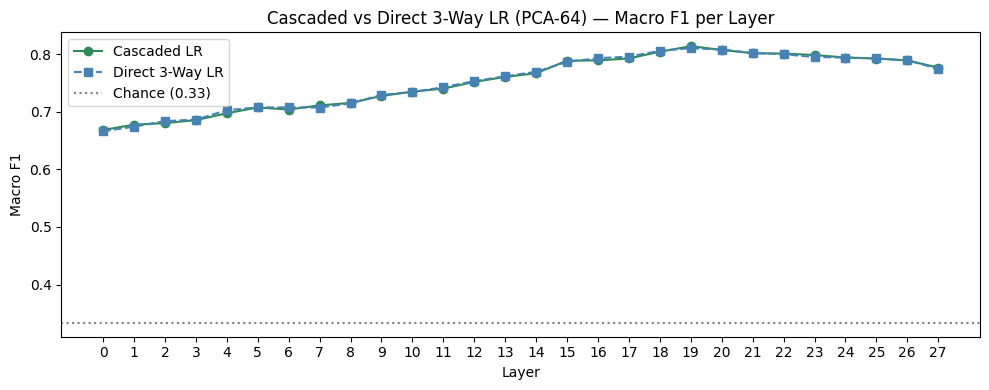

Saved cascaded_lr_vs_3way_macro_f1.png


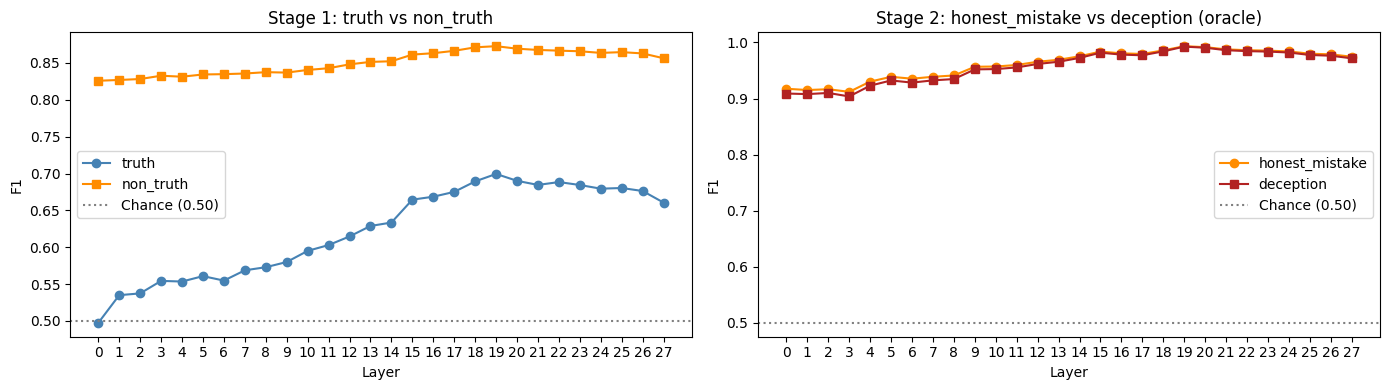

Saved cascaded_lr_stage_f1s.png


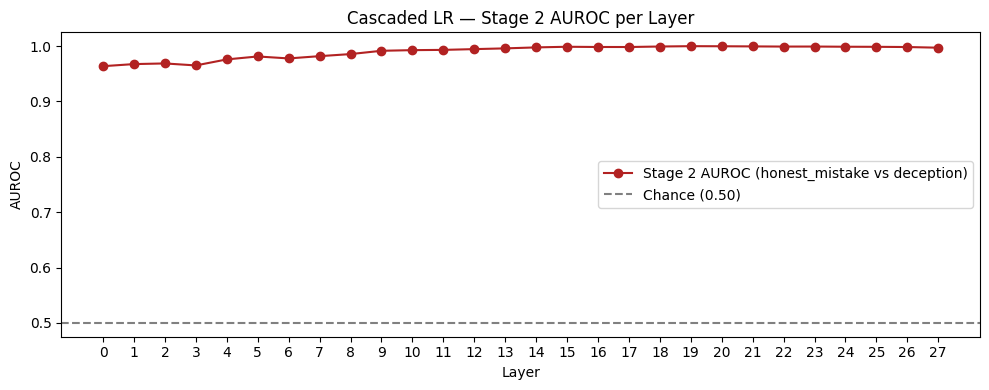

Saved cascaded_lr_stage2_auroc.png


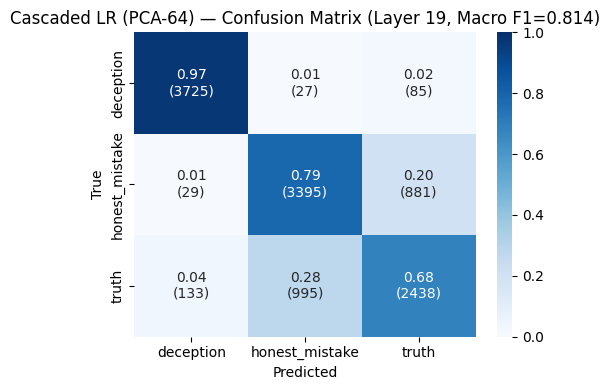

Saved cascaded_lr_confusion_matrix_layer19.png


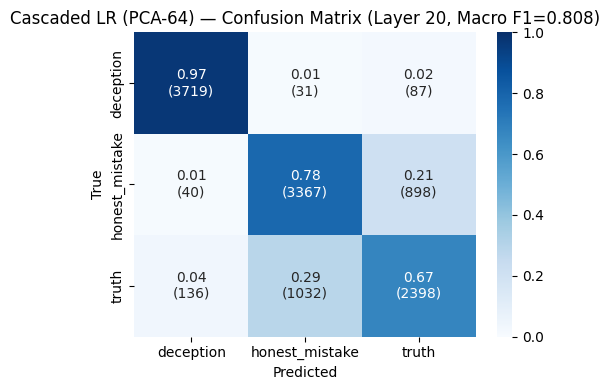

Saved cascaded_lr_confusion_matrix_layer20.png


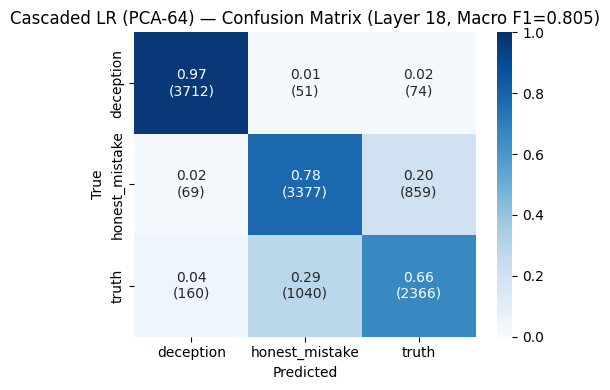

Saved cascaded_lr_confusion_matrix_layer18.png


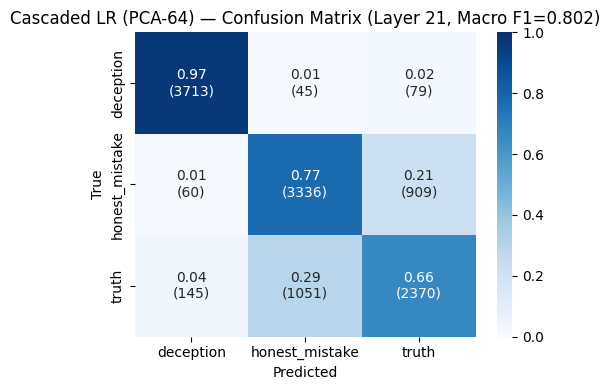

Saved cascaded_lr_confusion_matrix_layer21.png


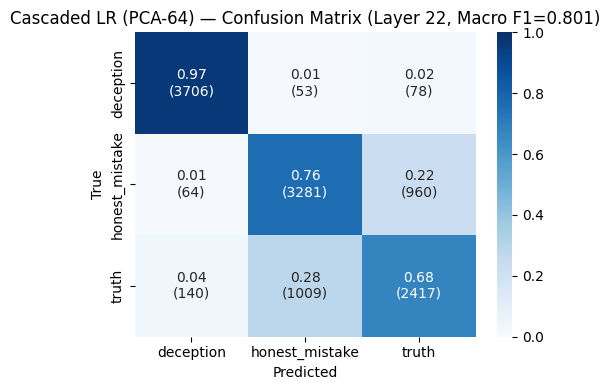

Saved cascaded_lr_confusion_matrix_layer22.png


In [81]:
import pickle
from utils.probe import probe_all_layers_cascaded, train_cascaded_probe
from utils.analysis import save_results_csv

CHECKPOINT_CASCADED_PATH = OUTPUT_DIR / "probe_results_cascaded_lr_checkpoint.pkl"
RESULTS_CASCADED_PATH    = OUTPUT_DIR / "probe_results_cascaded_lr.csv"

# ── Skip if results already exist ────────────────────────────────────────
if RESULTS_CASCADED_PATH.exists():
    df_cascaded = pd.read_csv(RESULTS_CASCADED_PATH)
    print(f"[skip] probe_results_cascaded_lr.csv already exists ({len(df_cascaded)} rows) — skipping probe run.")
    print(df_cascaded[["layer", "f1_macro", "f1_truth", "f1_honest_mistake", "f1_deception", "stage2_auroc"]].to_string(index=False))
else:
    n_layers = acts_reduced.shape[1]

    # ── Load checkpoint if exists ─────────────────────────────────────────
    if CHECKPOINT_CASCADED_PATH.exists():
        with open(CHECKPOINT_CASCADED_PATH, "rb") as f:
            results_cascaded = pickle.load(f)
        done_layers = {r["layer"] for r in results_cascaded}
        print(f"[checkpoint] Resuming from layer {max(done_layers)+1} ({len(done_layers)}/{n_layers} done)")
    else:
        results_cascaded = []
        done_layers = set()
        print("Starting fresh cascaded LR probe (PCA-64)...")

    # ── Run remaining layers ──────────────────────────────────────────────
    from tqdm.auto import tqdm
    remaining = [i for i in range(n_layers) if i not in done_layers]
    for layer_idx in tqdm(remaining, desc="cascaded LR probe (layers)"):
        layer_acts = acts_reduced[:, layer_idx, :]
        result = train_cascaded_probe(layer_acts, labels_str)
        result["layer"] = layer_idx
        results_cascaded.append(result)
        results_cascaded.sort(key=lambda r: r["layer"])
        with open(CHECKPOINT_CASCADED_PATH, "wb") as f:
            pickle.dump(results_cascaded, f)

    print(f"All {n_layers} layers done.")
    df_cascaded = save_results_csv(results_cascaded, RESULTS_CASCADED_PATH)
    print(f"Saved probe_results_cascaded_lr.csv ({len(df_cascaded)} rows)")
    print(df_cascaded[["layer", "f1_macro", "f1_truth", "f1_honest_mistake", "f1_deception", "stage2_auroc"]].to_string(index=False))

layers = df_cascaded["layer"].values
chance = 1 / 3

# ── Plot 1: Macro F1 per layer (cascaded vs direct 3-way) ────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(layers, df_cascaded["f1_macro"], marker="o", color="seagreen",  label="Cascaded LR")
ax.plot(layers, df_3way["f1_macro"],     marker="s", color="steelblue", label="Direct 3-Way LR", linestyle="--")
ax.axhline(chance, color="gray", linestyle=":", label=f"Chance ({chance:.2f})")
ax.set_xlabel("Layer")
ax.set_ylabel("Macro F1")
ax.set_title("Cascaded vs Direct 3-Way LR (PCA-64) — Macro F1 per Layer")
ax.legend()
ax.set_xticks(layers)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "cascaded_lr_vs_3way_macro_f1.png", dpi=150)
plt.show()
print("Saved cascaded_lr_vs_3way_macro_f1.png")

# ── Plot 2: Stage F1s per layer ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

ax1 = axes[0]
ax1.plot(layers, df_cascaded["stage1_f1_truth"],     marker="o", color="steelblue",  label="truth")
ax1.plot(layers, df_cascaded["stage1_f1_non_truth"], marker="s", color="darkorange", label="non_truth")
ax1.axhline(0.5, color="gray", linestyle=":", label="Chance (0.50)")
ax1.set_xlabel("Layer")
ax1.set_ylabel("F1")
ax1.set_title("Stage 1: truth vs non_truth")
ax1.legend()
ax1.set_xticks(layers)

ax2 = axes[1]
ax2.plot(layers, df_cascaded["stage2_f1_honest_mistake"], marker="o", color="darkorange", label="honest_mistake")
ax2.plot(layers, df_cascaded["stage2_f1_deception"],      marker="s", color="firebrick",  label="deception")
ax2.axhline(0.5, color="gray", linestyle=":", label="Chance (0.50)")
ax2.set_xlabel("Layer")
ax2.set_ylabel("F1")
ax2.set_title("Stage 2: honest_mistake vs deception (oracle)")
ax2.legend()
ax2.set_xticks(layers)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "cascaded_lr_stage_f1s.png", dpi=150)
plt.show()
print("Saved cascaded_lr_stage_f1s.png")

# ── Plot 3: Stage 2 AUROC per layer ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(layers, df_cascaded["stage2_auroc"], marker="o", color="firebrick", label="Stage 2 AUROC (honest_mistake vs deception)")
ax.axhline(0.5, color="gray", linestyle="--", label="Chance (0.50)")
ax.set_xlabel("Layer")
ax.set_ylabel("AUROC")
ax.set_title("Cascaded LR — Stage 2 AUROC per Layer")
ax.legend()
ax.set_xticks(layers)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "cascaded_lr_stage2_auroc.png", dpi=150)
plt.show()
print("Saved cascaded_lr_stage2_auroc.png")

# ── Plot 4: Confusion matrices for top 5 layers ───────────────────────────
import seaborn as sns

top5_layers = df_cascaded.nlargest(5, "f1_macro")["layer"].tolist()

for layer_idx in top5_layers:
    if RESULTS_CASCADED_PATH.exists() and not CHECKPOINT_CASCADED_PATH.exists():
        print(f"[skip] confusion matrix not available when loaded from CSV (layer {layer_idx})")
        continue
    r = results_cascaded[layer_idx]
    classes   = r["classes"]
    cm_norm   = r["confusion_matrix_norm"]
    cm_counts = r["confusion_matrix"]
    n = len(classes)

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm_norm,
        annot=[[f"{cm_norm[i,j]:.2f}\n({cm_counts[i,j]})" for j in range(n)] for i in range(n)],
        fmt="",
        xticklabels=classes,
        yticklabels=classes,
        cmap="Blues",
        vmin=0, vmax=1,
        ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"Cascaded LR (PCA-64) — Confusion Matrix (Layer {layer_idx:02d}, Macro F1={r['f1_macro']:.3f})")
    fig.tight_layout()
    fname = FIGURES_DIR / f"cascaded_lr_confusion_matrix_layer{layer_idx:02d}.png"
    fig.savefig(fname, dpi=150)
    plt.show()
    print(f"Saved cascaded_lr_confusion_matrix_layer{layer_idx:02d}.png")


### 6.5 Approach 4: 2-Stage MLP Classifier

In [ ]:
import pickle
from utils.probe import train_cascaded_mlp_probe
from tqdm.auto import tqdm

CHECKPOINT_CASCADED_MLP_PATH = OUTPUT_DIR / "probe_results_cascaded_mlp_checkpoint.pkl"
RESULTS_CASCADED_MLP_PATH    = OUTPUT_DIR / "probe_results_cascaded_mlp.csv"

# ── Skip if results already exist ────────────────────────────────────────
if RESULTS_CASCADED_MLP_PATH.exists():
    df_cascaded_mlp = pd.read_csv(RESULTS_CASCADED_MLP_PATH)
    print(f"[skip] probe_results_cascaded_mlp.csv already exists ({len(df_cascaded_mlp)} rows) — skipping probe run.")
    print(df_cascaded_mlp[["layer", "f1_macro", "f1_truth", "f1_honest_mistake", "f1_deception", "stage2_auroc"]].to_string(index=False))
else:
    if 'acts_reduced' not in dir():
        acts_reduced = np.load(OUTPUT_DIR / 'activations_pca64.npy')
        print(f'Loaded acts_reduced from disk: {acts_reduced.shape}')
    n_layers = acts_reduced.shape[1]

    if CHECKPOINT_CASCADED_MLP_PATH.exists():
        with open(CHECKPOINT_CASCADED_MLP_PATH, "rb") as f:
            results_cascaded_mlp = pickle.load(f)
        done_layers = {r["layer"] for r in results_cascaded_mlp}
        print(f"[checkpoint] Resuming from layer {max(done_layers)+1} ({len(done_layers)}/{n_layers} done)")
    else:
        results_cascaded_mlp = []
        done_layers = set()
        print("Starting fresh cascaded MLP probe (PCA-64)...")

    remaining = [i for i in range(n_layers) if i not in done_layers]
    for layer_idx in tqdm(remaining, desc="cascaded MLP probe (layers)"):
        layer_acts = acts_reduced[:, layer_idx, :]
        result = train_cascaded_mlp_probe(layer_acts, labels_str)
        result["layer"] = layer_idx
        results_cascaded_mlp.append(result)
        results_cascaded_mlp.sort(key=lambda r: r["layer"])
        with open(CHECKPOINT_CASCADED_MLP_PATH, "wb") as f:
            pickle.dump(results_cascaded_mlp, f)

    print(f"All {n_layers} layers done.")
    df_cascaded_mlp = save_results_csv(results_cascaded_mlp, RESULTS_CASCADED_MLP_PATH)
    print(f"Saved probe_results_cascaded_mlp.csv ({len(df_cascaded_mlp)} rows)")
    print(df_cascaded_mlp[["layer", "f1_macro", "f1_truth", "f1_honest_mistake", "f1_deception", "stage2_auroc"]].to_string(index=False))

layers = df_cascaded_mlp["layer"].values
chance = 1 / 3

# ── Plot 1: Macro F1 per layer (cascaded MLP vs cascaded LR vs direct 3-way) ─
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(layers, df_cascaded_mlp["f1_macro"], marker="o", color="seagreen",   label="Cascaded MLP (256,)")
ax.plot(layers, df_cascaded["f1_macro"],     marker="s", color="mediumorchid", label="Cascaded LR", linestyle="--")
ax.plot(layers, df_3way["f1_macro"],         marker="^", color="steelblue",  label="Direct 3-Way LR", linestyle=":")
ax.axhline(chance, color="gray", linestyle=":", label=f"Chance ({chance:.2f})")
ax.set_xlabel("Layer")
ax.set_ylabel("Macro F1")
ax.set_title("Cascaded MLP vs Cascaded LR vs Direct 3-Way (PCA-64) — Macro F1 per Layer")
ax.legend()
ax.set_xticks(layers)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "cascaded_mlp_vs_lr_macro_f1.png", dpi=150)
plt.show()
print("Saved cascaded_mlp_vs_lr_macro_f1.png")

# ── Plot 2: Stage F1s per layer ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

ax1 = axes[0]
ax1.plot(layers, df_cascaded_mlp["stage1_f1_truth"],     marker="o", color="steelblue",  label="truth")
ax1.plot(layers, df_cascaded_mlp["stage1_f1_non_truth"], marker="s", color="darkorange", label="non_truth")
ax1.axhline(0.5, color="gray", linestyle=":", label="Chance (0.50)")
ax1.set_xlabel("Layer")
ax1.set_ylabel("F1")
ax1.set_title("Stage 1: truth vs non_truth")
ax1.legend()
ax1.set_xticks(layers)

ax2 = axes[1]
ax2.plot(layers, df_cascaded_mlp["stage2_f1_honest_mistake"], marker="o", color="darkorange", label="honest_mistake")
ax2.plot(layers, df_cascaded_mlp["stage2_f1_deception"],      marker="s", color="firebrick",  label="deception")
ax2.axhline(0.5, color="gray", linestyle=":", label="Chance (0.50)")
ax2.set_xlabel("Layer")
ax2.set_ylabel("F1")
ax2.set_title("Stage 2: honest_mistake vs deception (oracle)")
ax2.legend()
ax2.set_xticks(layers)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "cascaded_mlp_stage_f1s.png", dpi=150)
plt.show()
print("Saved cascaded_mlp_stage_f1s.png")

# ── Plot 3: Stage 2 AUROC per layer ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(layers, df_cascaded_mlp["stage2_auroc"], marker="o", color="firebrick",    label="Cascaded MLP Stage 2 AUROC")
ax.plot(layers, df_cascaded["stage2_auroc"],     marker="s", color="mediumorchid", label="Cascaded LR Stage 2 AUROC", linestyle="--")
ax.axhline(0.5, color="gray", linestyle="--", label="Chance (0.50)")
ax.set_xlabel("Layer")
ax.set_ylabel("AUROC")
ax.set_title("Cascaded MLP vs LR — Stage 2 AUROC per Layer")
ax.legend()
ax.set_xticks(layers)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "cascaded_mlp_vs_lr_stage2_auroc.png", dpi=150)
plt.show()
print("Saved cascaded_mlp_vs_lr_stage2_auroc.png")

# ── Plot 4: Confusion matrices for top 5 layers ───────────────────────────
import seaborn as sns

top5_layers = df_cascaded_mlp.nlargest(5, "f1_macro")["layer"].tolist()

for layer_idx in top5_layers:
    if RESULTS_CASCADED_MLP_PATH.exists() and not CHECKPOINT_CASCADED_MLP_PATH.exists():
        print(f"[skip] confusion matrix not available when loaded from CSV (layer {layer_idx})")
        continue
    r = results_cascaded_mlp[layer_idx]
    classes   = r["classes"]
    cm_norm   = r["confusion_matrix_norm"]
    cm_counts = r["confusion_matrix"]
    n = len(classes)

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm_norm,
        annot=[[f"{cm_norm[i,j]:.2f}\n({cm_counts[i,j]})" for j in range(n)] for i in range(n)],
        fmt="",
        xticklabels=classes,
        yticklabels=classes,
        cmap="Blues",
        vmin=0, vmax=1,
        ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"Cascaded MLP (PCA-64) — Confusion Matrix (Layer {layer_idx:02d}, Macro F1={r['f1_macro']:.3f})")
    fig.tight_layout()
    fname = FIGURES_DIR / f"cascaded_mlp_confusion_matrix_layer{layer_idx:02d}.png"
    fig.savefig(fname, dpi=150)
    plt.show()
    print(f"Saved cascaded_mlp_confusion_matrix_layer{layer_idx:02d}.png")
